# NOEMA — Phase 1 in one notebook
**Semantic-entropy distillation into an intrinsic precision head (H2), with gate analysis (H4).**

This notebook in the repo root (`NOEMA/noema/`) and run cells top to bottom.
Real model + real data: Qwen2.5-1.5B-Instruct on TriviaQA, DeBERTa-MNLI as entailment judge.
First run downloads ~5 GB of weights.

In [ ]:
# 1) Dependencies (one-time; restart kernel after first install)
%pip install -q numpy torch transformers datasets accelerate matplotlib tqdm truststore

In [27]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"        # plain resumable HTTPS instead of chunked Xet
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "60"  # tolerate slow proxy handshakes
import truststore; truststore.inject_into_ssl()

In [28]:
# 2) Imports, path, device auto-detection
import os, sys, json, numpy as np, torch
sys.path.insert(0, os.path.abspath("."))   # notebook must sit in the repo root

from noema.semantic_entropy import NormalizedMatch, cluster_by_meaning, semantic_entropy
from noema.precision_head import TorchPrecisionHead, train_head
from noema.metrics import auroc, ece, risk_coverage
from noema.gate import fit_generate_threshold, gate_outcomes

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
print(f"device={DEVICE}  dtype={DTYPE}")

device=mps  dtype=torch.float32


In [29]:
# 3) Sanity checks (synthetic, instant) — pipeline logic must pass before spending compute
%run tests/test_pipeline.py
print()
%run experiments/mock_demo.py

PASS test_auroc_sanity
PASS test_clustering_merges_paraphrases
PASS test_ece_perfect_calibration
PASS test_gate_logic
PASS test_risk_coverage_monotone_setup
PASS test_semantic_entropy_bounds
PASS test_threshold_meets_target_risk

7/7 tests passed

=== NOEMA mock pipeline (synthetic world, n=1200) ===
Confabulation base rate:            0.513
AUROC  sampled semantic entropy:    0.937   (10 forward passes)
AUROC  distilled precision probe:   0.863   (1 forward pass)
H2 check (probe >= 90% of SE AUROC): PASS

ECE of precision estimate:          0.055
AURC (selective prediction):        0.241

Gate @ 10% target risk on answered:
  coverage:                         0.267
  risk among answered:              0.100   (base error 0.513)
  errors converted to abstention:   0.948

H4 shape confirmed: accuracy on answered rises because errors are
abstained, not because the worldless prior learned anything true.


## Configuration
Start small (`N=100, K=5`) to smoke-test, then raise to `N=2000, K=10` for the real run.
`LAYER=-6` follows the SEP finding that middle-late layers carry the uncertainty signal — sweep it later.

In [30]:
# 4) Config
MODEL   = "Qwen/Qwen2.5-1.5B-Instruct"
NLI = "microsoft/deberta-large-mnli"
DATASET = "nq_open"        # or "simpleqa" for the OOD check
N       = 500              # -> 2000 for the real run
K       = 10                 # sampled answers per question -> 10 for the real run
LAYER   = -6
OUT     = f"phase1_{DATASET}_n{N}"
os.makedirs(OUT, exist_ok=True)

In [31]:
# 5) Load generator model + entailment judge
from transformers import AutoModelForCausalLM, AutoTokenizer
from noema.semantic_entropy import HFEntailment

os.environ["HF_TOKEN"] ='hf_REDACTED'
tok = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=DTYPE).to(DEVICE).eval()
entail = HFEntailment(NLI, device=DEVICE)
match = NormalizedMatch()
print("models loaded")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

[transformers] DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-large-mnli
Key    | Status     |  | 
-------+------------+--+-
config | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


models loaded


In [32]:
# 6) Load real QA data
from datasets import load_dataset

if DATASET == "triviaqa":
    ds = load_dataset("mandarjoshi/trivia_qa", "rc.nocontext", split="validation")
    items = [(x["question"], x["answer"]["value"]) for x in ds.select(range(N))]
elif DATASET == "nq_open":
    ds = load_dataset("google-research-datasets/nq_open", split="validation")
    items = [(x["question"], " ||| ".join(x["answer"])) for x in ds.select(range(N))]
elif DATASET == "simpleqa":
    ds = load_dataset("basicv8vc/SimpleQA", split="test")
    items = [(x["problem"], x["answer"]) for x in ds.select(range(N))]
print(f"{len(items)} items   e.g. {items[0]}")



README.md:   0%|          | 0.00/8.77k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/4.46M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/214k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87925 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3610 [00:00<?, ? examples/s]

500 items   e.g. ('when was the last time anyone was on the moon', '14 December 1972 UTC ||| December 1972')


In [33]:
# 7) Data collection: greedy answer, K samples, hidden state, semantic entropy
#    Checkpoints every 50 items -> safe to interrupt and rerun.
from tqdm.auto import tqdm

@torch.no_grad()
def answer_and_states(question, max_new=32):
    prompt = f"Answer the question as briefly as possible.\nQ: {question}\nA:"
    enc = tok(prompt, return_tensors="pt").to(DEVICE)
    hs = model(**enc, output_hidden_states=True).hidden_states[LAYER][0, -1]
    def gen(do_sample):
        out = model.generate(**enc, max_new_tokens=max_new, do_sample=do_sample,
                             temperature=1.0, top_p=0.95, pad_token_id=tok.eos_token_id)
        return tok.decode(out[0, enc.input_ids.shape[1]:],
                          skip_special_tokens=True).strip().split("\n")[0]
    return gen(False), [gen(True) for _ in range(K)], hs.float().cpu().numpy()

ckpt = os.path.join(OUT, "arrays.npz")
if os.path.exists(ckpt):
    z = np.load(ckpt, allow_pickle=True)
    H, SE, correct = list(z["H"]), list(z["SE"]), list(z["correct"])
    print(f"resuming from {len(H)} items")
else:
    H, SE, correct = [], [], []

for i in tqdm(range(len(H), len(items))):
    q, gold = items[i]
    greedy, samples, h = answer_and_states(q)
    ids = cluster_by_meaning(samples, lambda a, b: entail(a, b, question=q))
    H.append(h); SE.append(semantic_entropy(ids))
    golds = gold.split(' ||| ')
    correct.append(int(any(match(greedy, g) for g in golds)
                        or entail(greedy, golds[0], question=q)))
    if (i + 1) % 50 == 0 or i == len(items) - 1:
        np.savez(ckpt, H=np.array(H), SE=np.array(SE), correct=np.array(correct))

H = np.array(H); SE = np.array(SE); correct = np.array(correct)
confab = 1 - correct
print(f"\ndone: n={len(H)}  accuracy={correct.mean():.3f}  mean SE={SE.mean():.2f}")

  0%|          | 0/500 [00:00<?, ?it/s]


done: n=500  accuracy=0.224  mean SE=1.88


In [34]:
# 8) Train the precision head (SE distillation + asymmetric grounding loss)
n_tr = len(correct) // 2
Ht = torch.tensor(H, dtype=torch.float32)
head = TorchPrecisionHead(Ht.shape[1])
train_head(head, Ht[:n_tr], torch.tensor(SE[:n_tr], dtype=torch.float32),
           correct=torch.tensor(correct[:n_tr], dtype=torch.float32), device=DEVICE)
with torch.no_grad():
    pi = head(Ht[n_tr:].to(DEVICE)).cpu().numpy()
print("precision head trained")

precision head trained


In [35]:
# 9) H2 evaluation: does 1 forward pass match K forward passes?
se_te, confab_te, correct_te = SE[n_tr:], confab[n_tr:], correct[n_tr:]

results = {
    "auroc_sampled_se":     auroc(se_te, confab_te),
    "auroc_precision_head": auroc(-pi, confab_te),
    "ece":                  ece(pi, correct_te),
    "aurc":                 risk_coverage(pi, correct_te)[2],
}
results["H2_pass"] = bool(results["auroc_precision_head"]
                          >= 0.9 * results["auroc_sampled_se"])
th = fit_generate_threshold(pi, correct_te, target_risk=0.05)
results["gate@5%risk"] = gate_outcomes(pi, correct_te, th)

print(json.dumps(results, indent=2))
with open(os.path.join(OUT, "results.json"), "w") as f:
    json.dump(results, f, indent=2)

{
  "auroc_sampled_se": 0.7895316540561249,
  "auroc_precision_head": 0.7080739392778469,
  "ece": 0.21199982740623485,
  "aurc": 0.6684209087729585,
  "H2_pass": false,
  "gate@5%risk": {
    "coverage": 0.008,
    "risk_answered": 0.0,
    "base_error": 0.788,
    "errors_converted_to_abstention": 1.0
  }
}


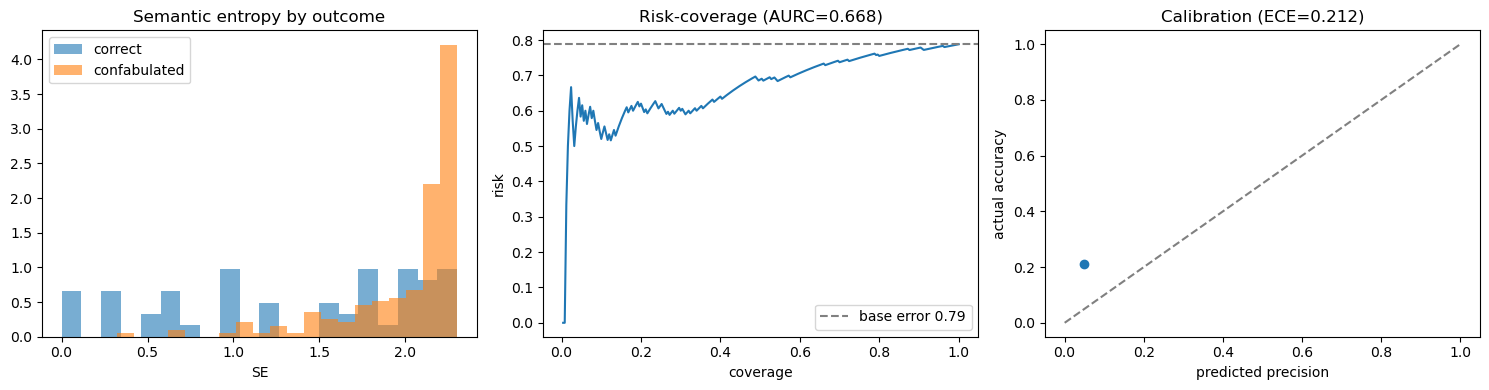

In [36]:
# 10) Plots: SE separates truth from confabulation; risk-coverage; calibration
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(se_te[confab_te == 0], bins=20, alpha=0.6, label="correct", density=True)
ax[0].hist(se_te[confab_te == 1], bins=20, alpha=0.6, label="confabulated", density=True)
ax[0].set_title("Semantic entropy by outcome"); ax[0].set_xlabel("SE"); ax[0].legend()

cov, risk, aurc = risk_coverage(pi, correct_te)
ax[1].plot(cov, risk); ax[1].axhline(1 - correct_te.mean(), ls="--", c="gray",
           label=f"base error {1-correct_te.mean():.2f}")
ax[1].set_title(f"Risk-coverage (AURC={aurc:.3f})")
ax[1].set_xlabel("coverage"); ax[1].set_ylabel("risk"); ax[1].legend()

bins = np.linspace(0, 1, 11); centers = (bins[:-1] + bins[1:]) / 2
acc = [correct_te[(pi > lo) & (pi <= hi)].mean() if ((pi > lo) & (pi <= hi)).any()
       else np.nan for lo, hi in zip(bins[:-1], bins[1:])]
ax[2].plot(centers, acc, "o-"); ax[2].plot([0, 1], [0, 1], "--", c="gray")
ax[2].set_title(f"Calibration (ECE={results['ece']:.3f})")
ax[2].set_xlabel("predicted precision"); ax[2].set_ylabel("actual accuracy")
plt.tight_layout(); plt.show()

## Next steps
- **Real run:** set `N=2000, K=10`, rerun from cell 4 (checkpointing resumes automatically).
- **Layer sweep:** rerun with `LAYER` in {-4, -6, -8, -10}; keep the best AUROC.
- **OOD (the real H2 test):** run with `DATASET="simpleqa"`, then train the head on the
  TriviaQA arrays and evaluate on the SimpleQA arrays — the head must transfer.
- Send `results.json` back for analysis; if H2 holds, Phase 2 is the attention-gating hooks.